In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = 'https://en.wikipedia.org/wiki/Premier_League_Golden_Glove'

tables = pd.read_html(url)

print(f"Total tables found: {len(tables)}")

golden_glove_df = tables[2]
golden_glove_df = golden_glove_df.drop(columns=['Ref(s)'])

golden_glove_df.to_csv('/users/josh/desktop/720056188/Data/golden_glove_winners.csv', index=False)

golden_glove_df.head()

Total tables found: 10


,Season,Player,Nationality,Club,Clean sheets
0,2004–05,Petr Čech (1),Czech Republic,Chelsea‡,24#
1,2005–06,Pepe Reina (1),Spain,Liverpool,20
2,2006–07,Pepe Reina (2),Spain,Liverpool,19
3,2007–08,Pepe Reina (3),Spain,Liverpool,18
4,2008–09,Edwin van der Sar,Netherlands,Manchester United‡,21


Text(0.5, 1.0, 'Premier League Highest Clean Sheets by Season')

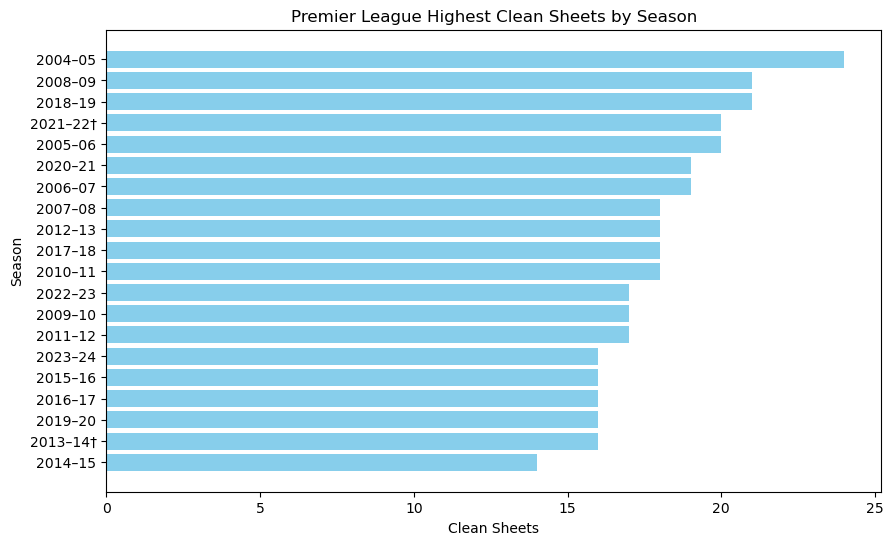

In [93]:
golden_glove_df['Clean sheets'] = golden_glove_df['Clean sheets'].replace('#', '', regex=True)
golden_glove_df['Clean sheets'] = pd.to_numeric(golden_glove_df['Clean sheets'], errors='coerce')
golden_glove_df = golden_glove_df.sort_values(by='Clean sheets', ascending=True)

x = golden_glove_df['Clean sheets']
y = golden_glove_df['Season']

plt.figure(figsize=(10, 6))
plt.barh(y, x, color='skyblue')
plt.xlabel('Clean Sheets')
plt.ylabel('Season')
plt.title('Premier League Highest Clean Sheets by Season')

In [101]:
Temperature_df = pd.read_csv('/users/josh/desktop/720056188/Data/Temperature.csv')
golden_glove_df = golden_glove_df.rename(columns={'Season':'date'})
golden_glove_df['date'] = golden_glove_df['date'].astype(str)
golden_glove_df['date'] = golden_glove_df['date'].str.split('–').str[0]
golden_glove_df = golden_glove_df.sort_values(by='date', ascending=True)

sorted_golden_glove_df = golden_glove_df.to_csv('/users/josh/desktop/720056188/Data/sorted_golden_glove.csv', index=False)
sorted_golden_glove_df = pd.read_csv('/users/josh/desktop/720056188/Data/sorted_golden_glove.csv')
sorted_golden_glove_df.head()

Kepper_Temperature_df = pd.merge(sorted_golden_glove_df, Temperature_df, on='date', how='left')
Kepper_Temperature_df = Kepper_Temperature_df.drop(columns=['1961 to 1990 long-term average' , '1991 to 2020 long-term average' , 'Annual mean temperature (trend)'])

keeper_temperature_df = Kepper_Temperature_df.to_csv('/users/josh/desktop/720056188/Data/Kepper_Temperature.csv', index=False)

Kepper_Temperature_df.head()



,date,Player,Nationality,Club,Clean sheets,Annual mean temperature
0,2004,Petr Čech (1),Czech Republic,Chelsea‡,24,9.44
1,2005,Pepe Reina (1),Spain,Liverpool,20,9.42
2,2006,Pepe Reina (2),Spain,Liverpool,19,9.70
3,2007,Pepe Reina (3),Spain,Liverpool,18,9.56
4,2008,Edwin van der Sar,Netherlands,Manchester United‡,21,9.02


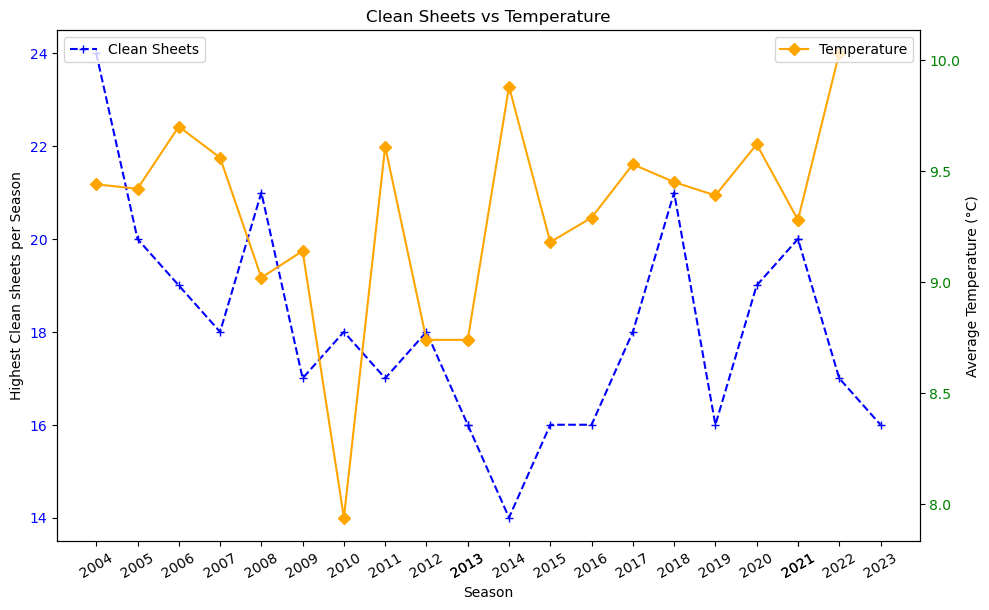

In [102]:
x = Kepper_Temperature_df['date']
Clean_Sheets = Kepper_Temperature_df['Clean sheets']
Temperature = Kepper_Temperature_df['Annual mean temperature']

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Season')
ax1.set_ylabel('Highest Clean sheets per Season')
ax1.plot(x, Clean_Sheets, color= 'blue', marker = '+', linestyle='--', label='Clean Sheets')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(x, rotation = 30)
plt.legend(loc = 'upper left')

ax2 = ax1.twinx()  
ax2.set_ylabel('Average Temperature (°C)')  
ax2.plot(x, Temperature, color='Orange', marker = 'D', label='Temperature')
ax2.tick_params(axis='y', labelcolor='Green')
plt.legend(loc = 'upper right')

fig.tight_layout()  
plt.title('Clean Sheets vs Temperature')

plt.show()